Some notes

stationary series:
- roughly horizontal + no trend
- constant varience
- no patterns predictable in the long-term + no seasonality

Preview:
- make data stationary -> build model(s) -> reverse everything -> generate forecasts 
- the action of reversing is integrating part in the ARIMA (I)

non-stationary series:
- acf of non stationary data decreases slowly

differencing help stabilize the mean.

taking the second differencing: second-order differencing.

seasonal differencing:
- is difference between an observation and the corresping observation from the previous year. 
- closer to being stationary
- if not stationary after, non-stationary can be removed with further first difference


makes no difference which is done first (seasonal and first differencing). if seasonality strong take seasonal difference 

# 9.1 Stationary and differencing

In [54]:
import pandas as pd

google = (
    pd.read_csv("../data/tsibbledata/gafa_stock.csv", parse_dates=["Date"])
    .loc[lambda x: (x["Symbol"] == "GOOG") & (x["Date"].dt.year == 2015)]
    .rename(columns={"Date": "ds", "Close": "y"})
    .assign(unique_id="GOOG_Close")
    [["unique_id", "ds", "y"]]
    .reset_index(drop=True)
)

google

,unique_id,ds,y
0,GOOG_Close,2015-01-02,521.937744
1,GOOG_Close,2015-01-05,511.057617
2,GOOG_Close,2015-01-06,499.212799
3,GOOG_Close,2015-01-07,498.357513
4,GOOG_Close,2015-01-08,499.928864
...,...,...,...
247,GOOG_Close,2015-12-24,748.400024
248,GOOG_Close,2015-12-28,762.510010
249,GOOG_Close,2015-12-29,776.599976
250,GOOG_Close,2015-12-30,771.000000


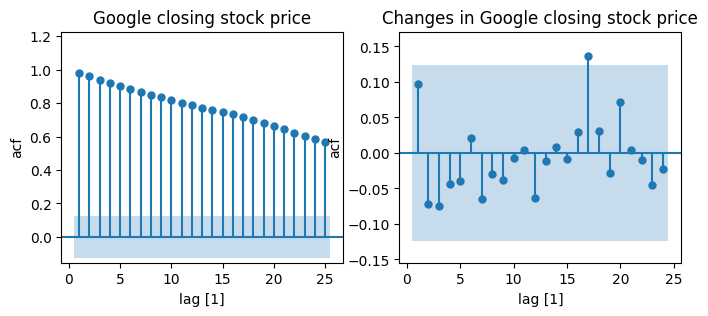

In [55]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
plot_acf(
    google["y"], ax=axes[0], zero=False,
    title="Google closing stock price",
    bartlett_confint=False, auto_ylims=True)
plot_acf(
    google["y"].diff().iloc[1:], ax=axes[1], zero=False,
    title="Changes in Google closing stock price",
    bartlett_confint=False, auto_ylims=True)
for ax in axes:
    ax.set(xlabel="lag [1]", ylabel="acf")
plt.show()

In [56]:
from statsmodels.stats.diagnostic import acorr_ljungbox


ljung_box = acorr_ljungbox(google["y"].diff()[1:], lags=[10])
ljung_box

,lb_stat,lb_pvalue
10,7.914143,0.637223


# 9.5 Non-seasonal ARIMA

/Users/omeraytug/Desktop/fpp3/.venv/lib/python3.13/site-packages/fpppy/utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


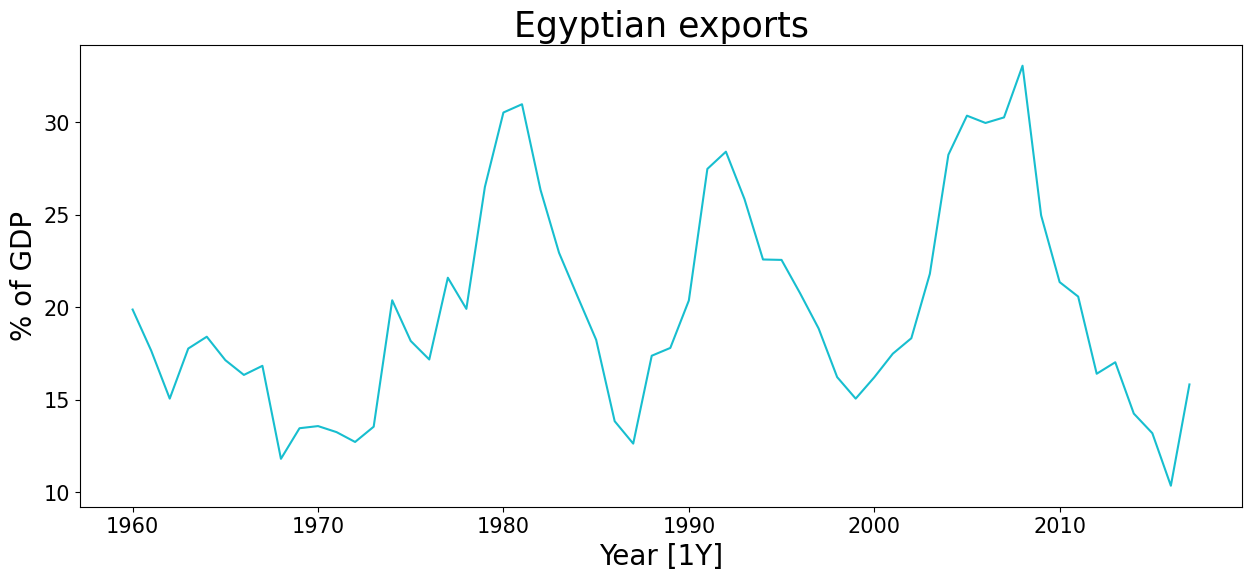

In [57]:
from fpppy.utils import plot_series

egyptian_economy = (
    pd.read_csv("../data/tsibbledata/global_economy.csv", parse_dates=["Year"])
    .loc[lambda x: x["Code"] == "EGY"]
    .rename(columns={"Year": "ds", "Exports": "y"})
    .assign(unique_id="Egypt")
    [["unique_id", "ds", "y"]]
    .reset_index(drop=True)
)

plot_series(
    egyptian_economy,
    xlabel="Year [1Y]", ylabel="% of GDP", title="Egyptian exports",
)

In [58]:
from statsforecast.models import ARIMA, AutoARIMA, AutoETS
from statsforecast.arima import ARIMASummary, ndiffs, nsdiffs
from statsforecast import StatsForecast

models = [AutoARIMA(allowmean=True)]
sf = StatsForecast(models=models, freq="YE", n_jobs=-1)
sf.fit(df=egyptian_economy)

model = sf.fitted_[0, 0].model_
coefs = {**model["coef"]}
coefs["mean"] = coefs.pop("intercept")
coefs = {k: round(v, 3) for k, v in coefs.items()}
coefs = pd.Series(coefs, name="Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(2)

print(ARIMASummary(model), "\n")
print(coefs.to_frame(), "\n")
print(metrics.to_frame())

ARIMA(2,0,1) with non-zero mean 

      Coefficients
ar1          1.676
ar2         -0.803
ma1         -0.690
mean        20.179 

         Metrics
sigma^2     8.05
loglik   -141.57
aic       293.13
aicc      294.29
bic       303.43


This is an ARIMA(2,0,1) model:

$y_t = c + 1.68y_{t-1} - 0.80y_{t-2} - 0.69\varepsilon_{t-1} + \varepsilon_t,$

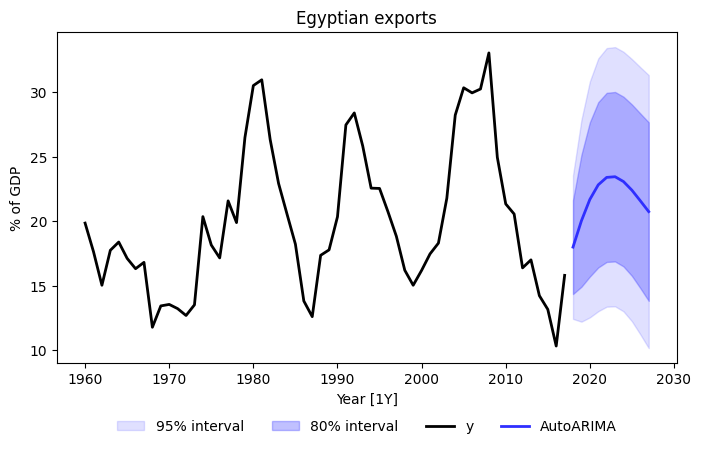

In [59]:
import matplotlib.pyplot as plt

levels = [80, 95]
fc = sf.predict(h=10, level=levels)

fig, ax = plt.subplots(figsize=(8, 4.3))

ax.fill_between(
    fc["ds"], fc["AutoARIMA-lo-95"], fc["AutoARIMA-hi-95"],
    color="#2f2fff", alpha=0.15, label="95% interval",
)
ax.fill_between(
    fc["ds"], fc["AutoARIMA-lo-80"], fc["AutoARIMA-hi-80"],
    color="#2f2fff", alpha=0.30, label="80% interval",
)
ax.plot(
    egyptian_economy["ds"], egyptian_economy["y"],
    color="black", linewidth=2, label="y",
)
ax.plot(
    fc["ds"], fc["AutoARIMA"],
    color="#2f2fff", linewidth=2, label="AutoARIMA",
)

ax.set_title("Egyptian exports")
ax.set_xlabel("Year [1Y]")
ax.set_ylabel("% of GDP")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)
plt.show()

# 9.7 ARIMA modelling in statsforecast

In [60]:
caf_economy = (
    pd.read_csv("../data/tsibbledata/global_economy.csv", parse_dates=["Year"])
    .loc[lambda x: x["Code"] == "CAF"]
    .rename(columns={"Year": "ds", "Exports": "y"})
    .assign(unique_id="Central African Republic")
    [["unique_id", "ds", "y"]]
    .reset_index(drop=True)
)

caf_economy.head()

,unique_id,ds,y
0,Central African Republic,1960-01-01,23.272724
1,Central African Republic,1961-01-01,26.490066
2,Central African Republic,1962-01-01,24.590165
3,Central African Republic,1963-01-01,25.236592
4,Central African Republic,1964-01-01,28.448269


/Users/omeraytug/Desktop/fpp3/.venv/lib/python3.13/site-packages/fpppy/utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


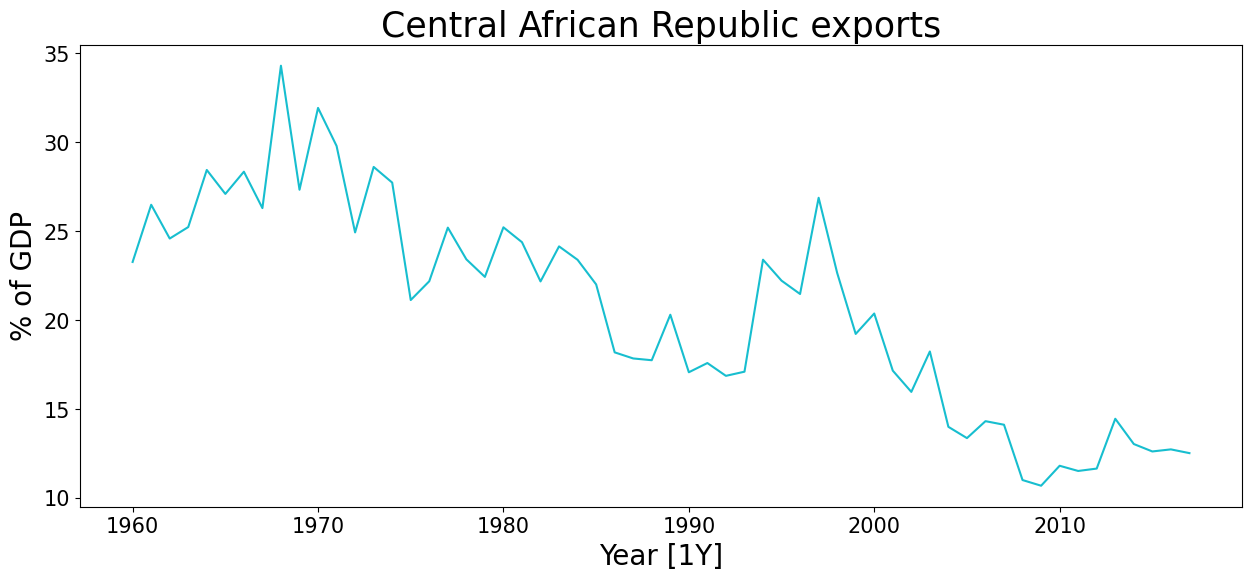

In [61]:
plot_series(caf_economy, xlabel="Year [1Y]", ylabel="% of GDP",
    title="Central African Republic exports")

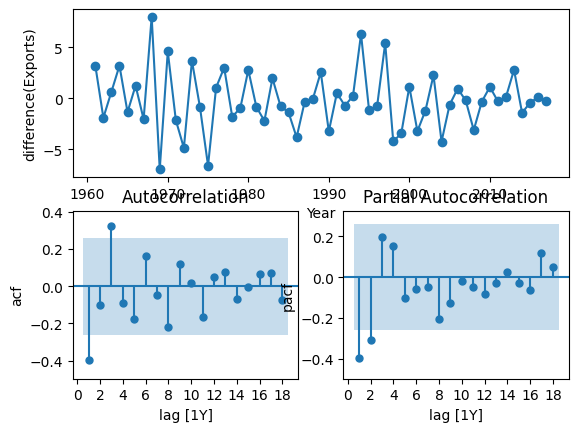

In [62]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df = caf_economy.assign(diff=caf_economy["y"].diff()).iloc[1:]
fig, axes = plt.subplot_mosaic([["diff", "diff"], ["acf", "pacf"]])

axes["diff"].plot(df["ds"], df["diff"], marker="o")
axes["diff"].set(xlabel="Year", ylabel="difference(Exports)")

plot_acf(
    df["diff"], ax=axes["acf"],
    zero=False, auto_ylims=True, bartlett_confint=False,
)
plot_pacf(
    df["diff"], ax=axes["pacf"],
    zero=False, auto_ylims=True,
)

axes["acf"].set(xlabel="lag [1Y]", ylabel="acf")
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["pacf"].set(xlabel="lag [1Y]", ylabel="pacf")
axes["pacf"].xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [63]:
models = [
    ARIMA(order=(2, 1, 0), alias="arima210"),
    ARIMA(order=(0, 1, 3), alias="arima013"),
    AutoARIMA(alias="stepwise"),
    AutoARIMA(stepwise=False, alias="search"),
]
sf = StatsForecast(models=models, freq="YE", n_jobs=-1)
sf.fit(caf_economy)
summaries = []
for model in sf.fitted_[0]:
    summary_model = {
        "model": model,
        "Orders": ARIMASummary(model.model_),
        "sigma2": model.model_["sigma2"],
        "loglik": model.model_["loglik"],
        "aic": model.model_["aic"],
        "aicc": model.model_["aicc"],
        "bic": model.model_["bic"],
    }
    summaries.append(summary_model)
pd.DataFrame(sorted(summaries, key=lambda d: d["aicc"]))

,model,Orders,sigma2,loglik,aic,aicc,bic
0,search,"ARIMA(3,1,0)",6.518527,-133.005829,274.011658,274.780889,282.183863
1,arima210,"ARIMA(2,1,0)",6.706196,-134.269488,274.538975,274.991805,280.668129
2,arima013,"ARIMA(0,1,3)",6.536673,-133.130383,274.260766,275.029997,282.432971
3,stepwise,"ARIMA(2,1,2)",6.416703,-132.124031,274.248061,275.424532,284.463317


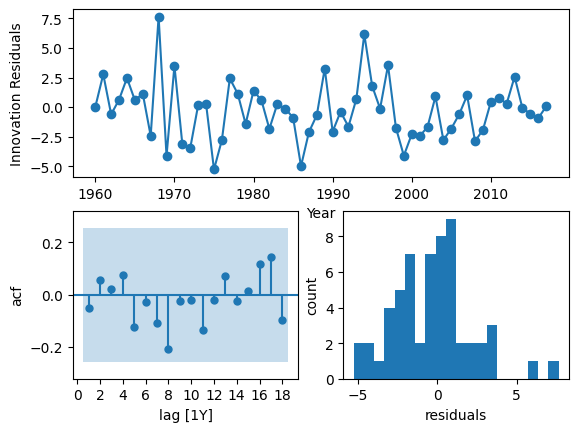

In [64]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from statsmodels.graphics.tsaplots import plot_acf

fc = sf.forecast(df=caf_economy, h=10, fitted=True, level=[80, 95])
insample = sf.forecast_fitted_values()
residuals = insample["y"] - insample["search"]

fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(insample["ds"], residuals, marker="o")
axes["resid"].set(xlabel="Year", ylabel="Innovation Residuals")

plot_acf(
    residuals, ax=axes["acf"],
    zero=False, auto_ylims=True, bartlett_confint=False,
)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1Y]", ylabel="acf", title="")

axes["hist"].hist(residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

In [65]:
ljung_box = acorr_ljungbox(residuals, lags=[10], model_df=3)
ljung_box

,lb_stat,lb_pvalue
10,5.703851,0.574723


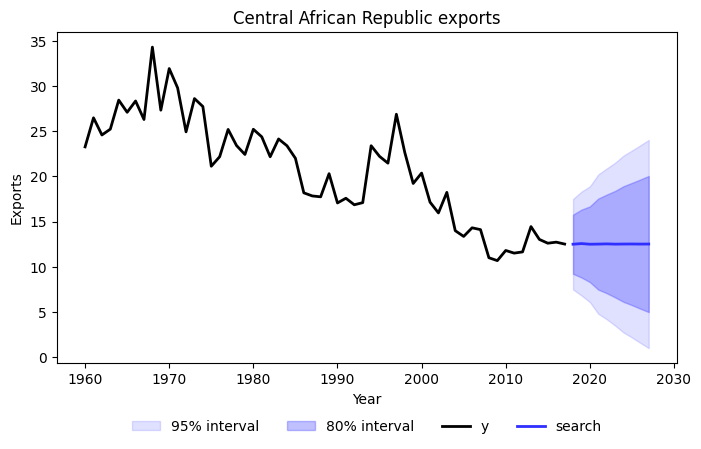

In [66]:
import matplotlib.pyplot as plt

search_columns = fc.columns[fc.columns.str.startswith("search")]
search_fc = fc[["unique_id", "ds", *search_columns]]

fig, ax = plt.subplots(figsize=(8, 4.3))

ax.fill_between(
    search_fc["ds"], search_fc["search-lo-95"], search_fc["search-hi-95"],
    color="#2f2fff", alpha=0.15, label="95% interval",
)
ax.fill_between(
    search_fc["ds"], search_fc["search-lo-80"], search_fc["search-hi-80"],
    color="#2f2fff", alpha=0.30, label="80% interval",
)
ax.plot(caf_economy["ds"], caf_economy["y"], color="black", linewidth=2, label="y")
ax.plot(search_fc["ds"], search_fc["search"], color="#2f2fff", linewidth=2, label="search")

ax.set_title("Central African Republic exports")
ax.set_xlabel("Year")
ax.set_ylabel("Exports")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)
plt.show()

# 9.9 Seasonal ARIMA models

## example 1: monthly us leisure and hospitality employment

In [67]:
leisure = (
    pd.read_csv("../data/fpp3/us_employment.csv")
    .loc[lambda x: x["Title"] == "Leisure and Hospitality"]
    .assign(
        ds=lambda x: pd.to_datetime(x["Month"], format="%Y %b"),
        y=lambda x: x["Employed"] / 1e3,
        unique_id="Leisure and Hospitality",
    )
    .loc[lambda x: x["ds"] >= "2001"]
    .reset_index(drop=True)
    [["unique_id", "ds", "y"]]
)

/Users/omeraytug/Desktop/fpp3/.venv/lib/python3.13/site-packages/fpppy/utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


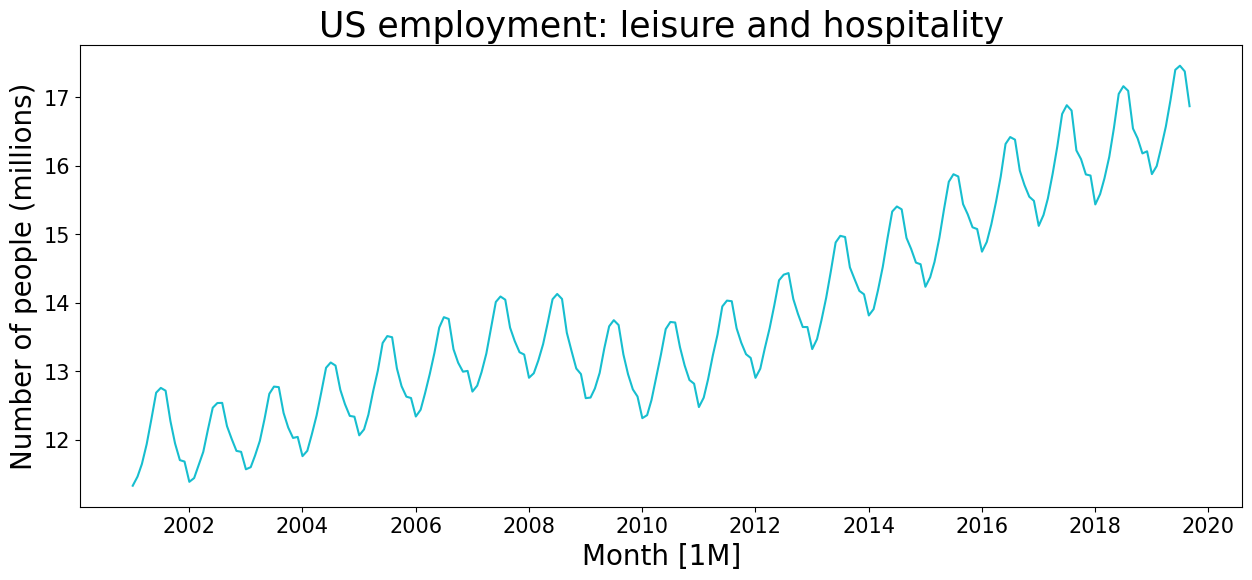

In [68]:
plot_series(leisure,
    xlabel="Month [1M]", ylabel="Number of people (millions)",
    title="US employment: leisure and hospitality")

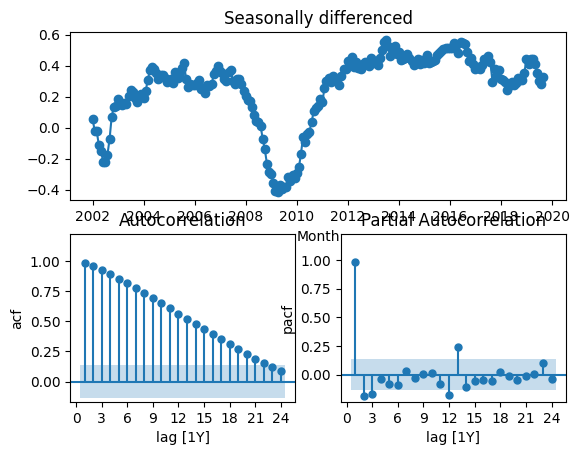

In [69]:
df = leisure.assign(diff=leisure["y"].diff(12)).iloc[12:]
fig, axes = plt.subplot_mosaic([["diff", "diff"], ["acf", "pacf"]])
axes["diff"].plot(df["ds"], df["diff"], marker="o")
axes["diff"].set(xlabel="Month", title="Seasonally differenced")
plot_acf(df["diff"], axes["acf"], lags=24,
    zero=False, auto_ylims=True, bartlett_confint=False)
plot_pacf(df["diff"], axes["pacf"], lags=24,
    zero=False, auto_ylims=True)
axes["acf"].set(xlabel="lag [1Y]", ylabel="acf")
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["pacf"].set(xlabel="lag [1Y]", ylabel="pacf")
axes["pacf"].xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

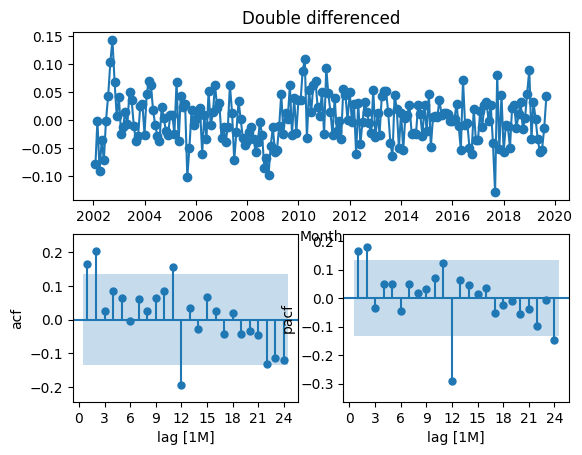

In [70]:
df = leisure.assign(
    diff=leisure["y"].diff(12),
    ddiff=lambda x: x["diff"].diff()
).iloc[13:]
fig, axes = plt.subplot_mosaic([["diff", "diff"], ["acf", "pacf"]])
axes["diff"].plot(df["ds"], df["ddiff"], marker="o")
axes["diff"].set(xlabel="Month", title="Double differenced")
plot_acf(df["ddiff"], axes["acf"], lags=24,
    zero=False, auto_ylims=True, bartlett_confint=False)
plot_pacf(df["ddiff"], axes["pacf"], lags=24,
    zero=False, auto_ylims=True)
axes["acf"].set(xlabel="lag [1M]", ylabel="acf", title="")
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["pacf"].set(xlabel="lag [1M]", ylabel="pacf", title="")
axes["pacf"].xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [71]:
models = [
    ARIMA(order=(0, 1, 2), seasonal_order=(0, 1, 1),
        season_length=12, alias="arima012011"),
    ARIMA(order=(2, 1, 0), seasonal_order=(0, 1, 1),
        season_length=12, alias="arima210011"),
    AutoARIMA(stepwise=False, approximation=False,
        alias="auto", season_length=12),
]
sf = StatsForecast(models=models, freq="MS", n_jobs=-1)
sf.fit(df=leisure)
summaries = []
for model in sf.fitted_[0]:
    summary_model = {
        "model": model,
        "Orders": ARIMASummary(model.model_),
        "sigma2": model.model_["sigma2"],
        "loglik": model.model_["loglik"],
        "aic": model.model_["aic"],
        "aicc": model.model_["aicc"],
        "bic": model.model_["bic"],
    }
    summaries.append(summary_model)
pd.DataFrame(sorted(summaries, key=lambda d: d["aicc"]))

,model,Orders,sigma2,loglik,aic,aicc,bic
0,auto,"ARIMA(2,1,0)(0,1,2)[12]",0.001426,394.469928,-778.939856,-778.648594,-762.156925
1,arima210011,"ARIMA(2,1,0)(0,1,1)[12]",0.001458,392.019894,-776.039789,-775.846552,-762.613444
2,arima012011,"ARIMA(0,1,2)(0,1,1)[12]",0.001469,391.292868,-774.585737,-774.392500,-761.159391


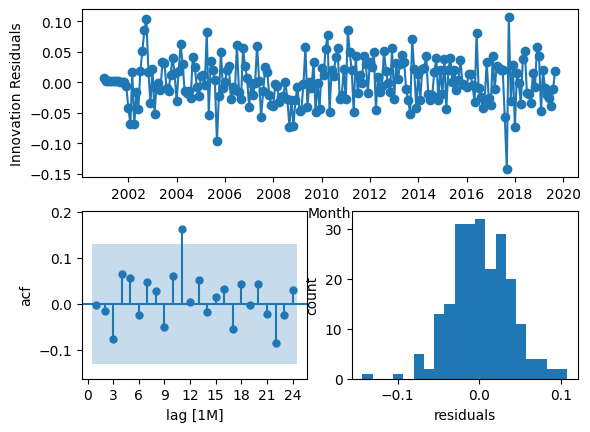

In [72]:
fc = sf.forecast(df=leisure, h=36, fitted=True, level=[80, 95])
insample = sf.forecast_fitted_values()
residuals = insample["y"] - insample["auto"]

fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(leisure["ds"], residuals, marker="o")
axes["resid"].set(xlabel="Month", ylabel="Innovation Residuals")
plot_acf(residuals, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1M]", ylabel="acf", title="")
axes["hist"].hist(residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

In [73]:
ljung_box = acorr_ljungbox(residuals, lags=[24], model_df=4)
ljung_box

,lb_stat,lb_pvalue
24,16.807533,0.665434


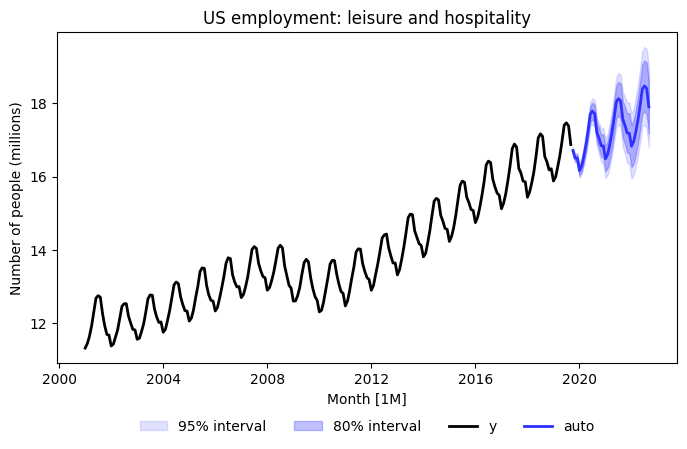

In [74]:
import matplotlib.pyplot as plt

auto_columns = fc.columns[fc.columns.str.startswith("auto")]
auto_fc = fc[["unique_id", "ds", *auto_columns]]

fig, ax = plt.subplots(figsize=(8, 4.3))

ax.fill_between(
    auto_fc["ds"], auto_fc["auto-lo-95"], auto_fc["auto-hi-95"],
    color="#2f2fff", alpha=0.15, label="95% interval",
)
ax.fill_between(
    auto_fc["ds"], auto_fc["auto-lo-80"], auto_fc["auto-hi-80"],
    color="#2f2fff", alpha=0.30, label="80% interval",
)
ax.plot(leisure["ds"], leisure["y"], color="black", linewidth=2, label="y")
ax.plot(auto_fc["ds"], auto_fc["auto"], color="#2f2fff", linewidth=2, label="auto")

ax.set_title("US employment: leisure and hospitality")
ax.set_xlabel("Month [1M]")
ax.set_ylabel("Number of people (millions)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)
plt.show()

## example 2: Corticosteroid drug sales in Australia

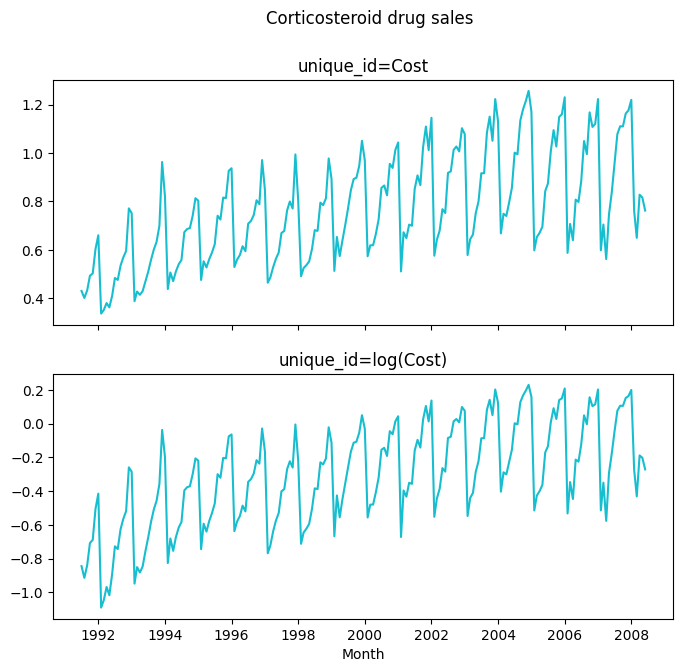

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from utilsforecast.plotting import plot_series as plot_series_utils

pbs = (
    pd.read_csv("../data/fpp3/PBS_unparsed.csv", parse_dates=["Month"])
    .rename(columns={"Month": "ds"})
    .loc[lambda x: x["ATC2"] == "H02"]
    .assign(Cost=lambda x: x["Cost"] / 1e6)
    .groupby("ds")["Cost"].sum().reset_index()
    .assign(**{"log(Cost)": lambda x: np.log(x["Cost"])})
    .melt(id_vars=["ds"], var_name="unique_id", value_name="y")
)

fig, axes = plt.subplots(2, figsize=(8, 7), sharex=True)
plot_series_utils(pbs, ax=axes)
for ax in axes:
    ax.set(ylabel="")
    if ax.get_legend():
        ax.get_legend().remove()
    for label in ax.get_xticklabels():
        label.set_rotation(0)
axes[-1].set(xlabel="Month")
fig.legends = []
fig.suptitle("Corticosteroid drug sales", x=0.52)
fig

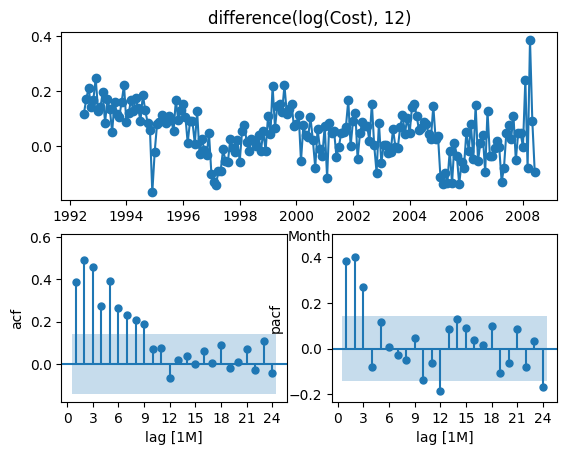

In [76]:
log_cost = pbs.loc[pbs["unique_id"] == "log(Cost)"]
df = log_cost.assign(diff=lambda x: x["y"].diff(12)).iloc[12:]
fig, axes = plt.subplot_mosaic([["diff", "diff"], ["acf", "pacf"]])
axes["diff"].plot(df["ds"], df["diff"], marker="o")
axes["diff"].set(xlabel="Month", title="difference(log(Cost), 12)")
plot_acf(df["diff"], axes["acf"], lags=24,
    zero=False, auto_ylims=True, bartlett_confint=False)
plot_pacf(df["diff"], axes["pacf"], lags=24,
    zero=False, auto_ylims=True)
axes["acf"].set(xlabel="lag [1M]", ylabel="acf", title="")
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["pacf"].set(xlabel="lag [1M]", ylabel="pacf", title="")
axes["pacf"].xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [77]:
models = [
    ARIMA(order=(3, 0, 0), seasonal_order=(2, 1, 0), season_length=12,
        alias="arima300210"),
    ARIMA(order=(3, 0, 1), seasonal_order=(2, 1, 0), season_length=12,
        alias="arima301210"),
    ARIMA(order=(3, 0, 2), seasonal_order=(2, 1, 0), season_length=12,
        alias="arima302210"),
    ARIMA(order=(3, 0, 1), seasonal_order=(1, 1, 0), season_length=12,
        alias="arima301110"),
    ARIMA(order=(3, 0, 1), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima301011"),
    ARIMA(order=(3, 0, 1), seasonal_order=(0, 1, 2), season_length=12,
        alias="arima301012"),
    ARIMA(order=(3, 0, 1), seasonal_order=(1, 1, 1), season_length=12,
        alias="arima301111"),
]
sf = StatsForecast(models=models, freq="MS", n_jobs=-1)
sf.fit(df=log_cost)
summaries = []
for model in sf.fitted_[0]:
    summary_model = {
        "Model": model,
        "Orders": ARIMASummary(model.model_),
        "AICc": model.model_["aicc"],
    }
    summaries.append(summary_model)
sorted_summaries = pd.DataFrame(sorted(summaries, key=lambda d: d["AICc"]))
sorted_summaries.sort_values("AICc")

,Model,Orders,AICc
0,arima301012,"ARIMA(3,0,1)(0,1,2)[12]",-482.842137
1,arima301011,"ARIMA(3,0,1)(0,1,1)[12]",-481.146638
2,arima301111,"ARIMA(3,0,1)(1,1,1)[12]",-479.318127
3,arima301210,"ARIMA(3,0,1)(2,1,0)[12]",-471.765218
4,arima302210,"ARIMA(3,0,2)(2,1,0)[12]",-469.914273
5,arima300210,"ARIMA(3,0,0)(2,1,0)[12]",-469.642079
6,arima301110,"ARIMA(3,0,1)(1,1,0)[12]",-462.216728


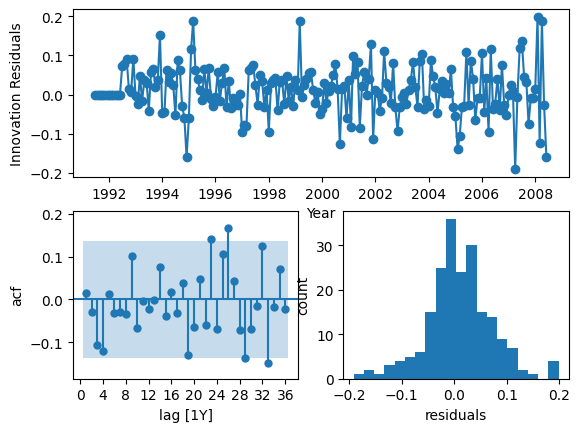

In [78]:
fc = sf.forecast(df=log_cost, h=24, fitted=True, level=[80, 95])
insample = sf.forecast_fitted_values()
residuals = insample["y"] - insample["arima301012"]

fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(insample["ds"], residuals, marker="o")
axes["resid"].set(xlabel="Year", ylabel="Innovation Residuals")
plot_acf(residuals, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False, lags=36)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1Y]", ylabel="acf", title="")
axes["hist"].hist(residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

In [79]:
ljung_box = acorr_ljungbox(residuals, lags=[36], model_df=6)
ljung_box

,lb_stat,lb_pvalue
36,50.630542,0.010656


In [80]:
models = [
    ARIMA(order=(3, 0, 0), seasonal_order=(2, 1, 0), season_length=12,
        alias="arima300210"),
    ARIMA(order=(3, 0, 1), seasonal_order=(2, 1, 0), season_length=12,
        alias="arima301210"),
    ARIMA(order=(3, 0, 2), seasonal_order=(2, 1, 0), season_length=12,
        alias="arima302210"),
    ARIMA(order=(3, 0, 1), seasonal_order=(1, 1, 0), season_length=12,
        alias="arima301110"),
    ARIMA(order=(3, 0, 1), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima301011"),
    ARIMA(order=(3, 0, 1), seasonal_order=(0, 1, 2), season_length=12,
        alias="arima301012"),
    ARIMA(order=(3, 0, 1), seasonal_order=(1, 1, 1), season_length=12,
        alias="arima301111"),
    ARIMA(order=(3, 0, 3), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima303011"),
    ARIMA(order=(3, 0, 2), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima302011"),
    ARIMA(order=(2, 1, 0), seasonal_order=(0, 1, 0), season_length=12,
        alias="arima210010"),
    ARIMA(order=(2, 1, 0), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima210011"),
    ARIMA(order=(2, 1, 0), seasonal_order=(1, 1, 0), season_length=12,
        alias="arima210110"),
    ARIMA(order=(2, 1, 1), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima211011"),
    ARIMA(order=(2, 1, 2), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima212011"),
    ARIMA(order=(2, 1, 3), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima213011"),
    ARIMA(order=(2, 1, 4), seasonal_order=(0, 1, 1), season_length=12,
        alias="arima214011"),
]

sf = StatsForecast(models=models, freq="MS", n_jobs=-1)
sf.fit(df=log_cost.iloc[:-24])
forecasts = sf.forecast(df=log_cost.iloc[:-24], h=24, level=[80, 95])
summaries = []
for model in sf.fitted_[0]:
    rmse_model = np.sqrt(
        np.mean(
            np.square(
                forecasts[str(model)].values-log_cost.iloc[-24:]["y"].values
            )
        )
    )
    summary_model = {
        "Model": model,
        "Orders": ARIMASummary(model.model_),
        "RMSE": rmse_model,
    }
    summaries.append(summary_model)
pd.DataFrame(sorted(summaries, key=lambda d: d["RMSE"]))

,Model,Orders,RMSE
0,arima213011,"ARIMA(2,1,3)(0,1,1)[12]",0.081959
1,arima214011,"ARIMA(2,1,4)(0,1,1)[12]",0.082141
2,arima212011,"ARIMA(2,1,2)(0,1,1)[12]",0.082595
3,arima211011,"ARIMA(2,1,1)(0,1,1)[12]",0.082608
4,arima210011,"ARIMA(2,1,0)(0,1,1)[12]",0.083078
5,arima301012,"ARIMA(3,0,1)(0,1,2)[12]",0.083900
6,arima303011,"ARIMA(3,0,3)(0,1,1)[12]",0.084384
7,arima302011,"ARIMA(3,0,2)(0,1,1)[12]",0.085188
8,arima301011,"ARIMA(3,0,1)(0,1,1)[12]",0.085194
9,arima301210,"ARIMA(3,0,1)(2,1,0)[12]",0.085871


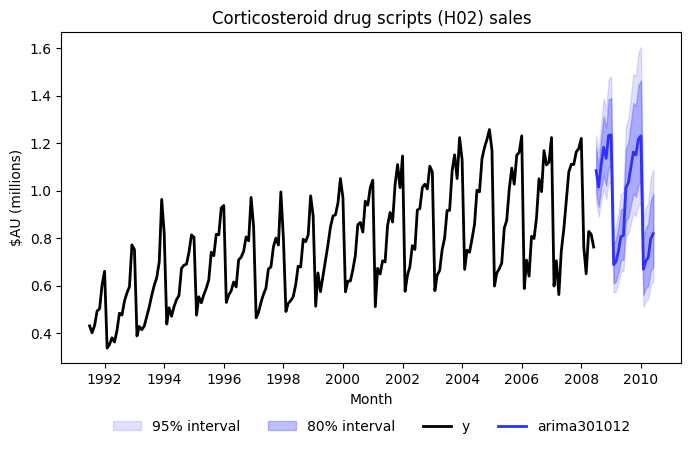

In [81]:
import matplotlib.pyplot as plt
import numpy as np

arima_cols = fc.columns[fc.columns.str.startswith("arima301012")]
backtransform_fc = fc[["ds", "unique_id"]].assign(**{
    col: np.exp(fc[col]) for col in arima_cols
})
df = log_cost.assign(y=lambda x: np.exp(x["y"]))

fig, ax = plt.subplots(figsize=(8, 4.3))

ax.fill_between(
    backtransform_fc["ds"], backtransform_fc["arima301012-lo-95"], backtransform_fc["arima301012-hi-95"],
    color="#2f2fff", alpha=0.15, label="95% interval",
)
ax.fill_between(
    backtransform_fc["ds"], backtransform_fc["arima301012-lo-80"], backtransform_fc["arima301012-hi-80"],
    color="#2f2fff", alpha=0.30, label="80% interval",
)
ax.plot(df["ds"], df["y"], color="black", linewidth=2, label="y")
ax.plot(
    backtransform_fc["ds"], backtransform_fc["arima301012"],
    color="#2f2fff", linewidth=2, label="arima301012",
)

ax.set_title("Corticosteroid drug scripts (H02) sales")
ax.set_xlabel("Month")
ax.set_ylabel("$AU (millions)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)
plt.show()

# 9.10 ARIMA vs ETS

## Comparing AutoARIMA() and AutoETS() on non-seasonal data


In [83]:
from utilsforecast.losses import rmse, mae

aus_economy = (
    pd.read_csv("../data/fpp3/aus_economy.csv", parse_dates=["ds"])
    .assign(y=lambda x: x["y"] / 1e6)
)
models = [AutoARIMA(), AutoETS()]
sf = StatsForecast(models=models, freq="A", n_jobs=-1)
cv_forecasts = sf.cross_validation(h=1, n_windows=10, df=aus_economy)

model_names = ["AutoARIMA", "AutoETS"]
rm = rmse(cv_forecasts, models=model_names, cutoff_col=None)
ma = mae(cv_forecasts, models=model_names, cutoff_col=None)
metrics = pd.concat([rm.assign(metric="RMSE"), ma.assign(metric="MAE")])
metrics[["metric", *model_names]]

,metric,AutoARIMA,AutoETS
0,RMSE,0.082288,0.130904
0,MAE,0.060373,0.113445


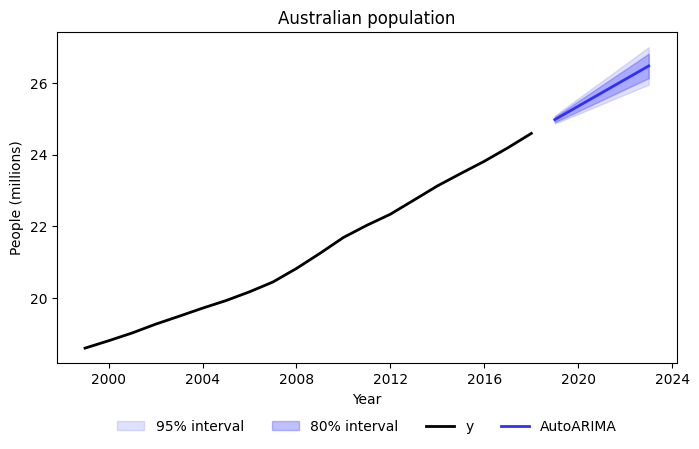

In [85]:
import matplotlib.pyplot as plt
from statsforecast.models import AutoARIMA
from statsforecast import StatsForecast

models = [AutoARIMA()]
sf = StatsForecast(models=models, freq="YE", n_jobs=-1)
level = [80, 95]
fc = sf.forecast(h=5, df=aus_economy, level=level)

hist = aus_economy.tail(20)

fig, ax = plt.subplots(figsize=(8, 4.3))

ax.fill_between(
    fc["ds"], fc["AutoARIMA-lo-95"], fc["AutoARIMA-hi-95"],
    color="#2f2fff", alpha=0.15, label="95% interval",
)
ax.fill_between(
    fc["ds"], fc["AutoARIMA-lo-80"], fc["AutoARIMA-hi-80"],
    color="#2f2fff", alpha=0.30, label="80% interval",
)
ax.plot(hist["ds"], hist["y"], color="black", linewidth=2, label="y")
ax.plot(fc["ds"], fc["AutoARIMA"], color="#2f2fff", linewidth=2, label="AutoARIMA")

ax.set_title("Australian population")
ax.set_xlabel("Year")
ax.set_ylabel("People (millions)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)
plt.show()

## Comparing AutoARIMA() and AutoETS() on seasonal data


In [87]:
aus_production = pd.read_csv("../data/tsibbledata/aus_production.csv")

cement = (
    aus_production.assign(
        ds=lambda x: pd.PeriodIndex(
            x["Quarter"].str.replace(" ", "", regex=False),
            freq="Q",
        ).to_timestamp()
    )
    .loc[lambda x: x["ds"] >= "1988"]
    [["ds", "Cement"]]
    .rename(columns={"Cement": "y"})
    .assign(unique_id="Cement")
)

train = cement.loc[lambda x: x["ds"] < "2008"].reset_index(drop=True)

In [88]:
arima = AutoARIMA(season_length=4, allowdrift=True)
arima_sf = StatsForecast(models=[arima], freq="QS", n_jobs=-1).fit(train)
arima_sf.forecast(df=train, h=10, fitted=True)
arima_insample = arima_sf.forecast_fitted_values()
arima_residuals = arima_insample["y"] - arima_insample["AutoARIMA"]

model = arima_sf.fitted_[0, 0].model_
coefs = {**model["coef"]}
coefs = pd.Series(coefs, name="Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(2)

print(ARIMASummary(model), "\n")
print(coefs.to_frame(), "\n")
print(metrics.to_frame())

ARIMA(1,0,0)(1,1,2)[4] with drift         

       Coefficients
ar1           0.781
sar1         -0.507
sma1         -0.083
sma2         -0.624
drift         9.339 

          Metrics
sigma^2  12314.39
loglik    -465.49
aic        942.98
aicc       944.20
bic        956.97


In [89]:
ljung_box = acorr_ljungbox(arima_residuals, lags=[16], model_df=5)
ljung_box

,lb_stat,lb_pvalue
16,11.17697,0.428559


In [90]:
ets = AutoETS(season_length=4)
ets_sf = StatsForecast(models=[ets], freq="QS", n_jobs=-1).fit(train)
ets_sf.forecast(df=train, h=10, fitted=True)
ets_insample = ets_sf.forecast_fitted_values()
ets_residuals = ets_insample["y"] - ets_insample["AutoETS"]

model = ets_sf.fitted_[0, 0].model_
params = model["fit"].x
params = pd.Series({
    "alpha": params[0], "gamma": params[1], "l[0]": params[2],
    "s[0]": params[3], "s[1]": params[4],
    "s[2]": params[5], "s[3]": 4 - params[-3:].sum(),
}, name="Parameters").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(3)

print(model["method"], "\n")
print(params.to_frame(), "\n")
print(metrics.to_frame())

ETS(M,N,M) 

       Parameters
alpha       0.744
gamma       0.000
l[0]     1567.027
s[0]        1.031
s[1]        1.045
s[2]        1.012
s[3]        0.913 

          Metrics
sigma^2     0.003
loglik   -544.103
aic      1102.206
aicc     1103.761
bic      1118.880


In [91]:
ljung_box = acorr_ljungbox(ets_residuals, lags=[16])
ljung_box

,lb_stat,lb_pvalue
16,11.644387,0.768076


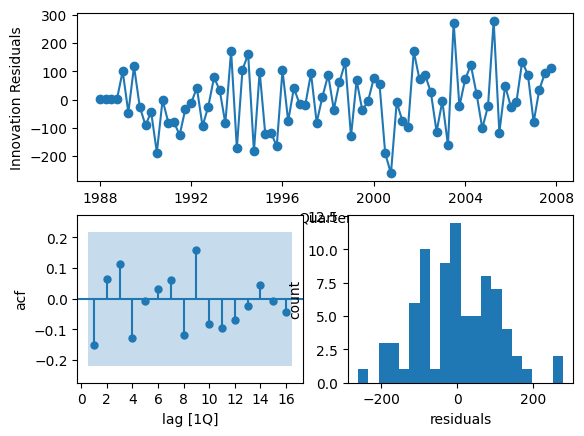

In [92]:
fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(arima_insample["ds"], arima_residuals, marker="o")
axes["resid"].set(xlabel="Quarter", ylabel="Innovation Residuals")
plot_acf(arima_residuals, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False, lags=16)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1Q]", ylabel="acf", title="")
axes["hist"].hist(arima_residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

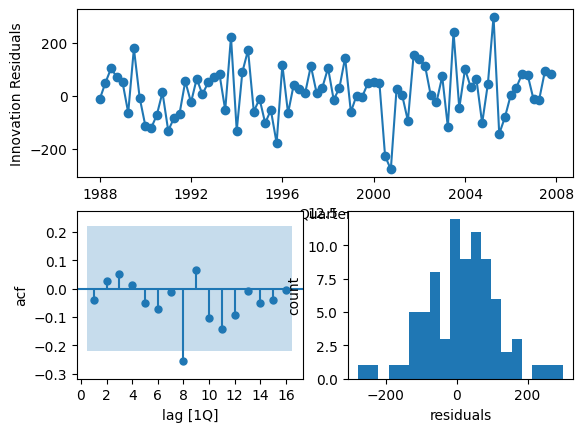

In [93]:
fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(ets_insample["ds"], ets_residuals, marker="o")
axes["resid"].set(xlabel="Quarter", ylabel="Innovation Residuals")
plot_acf(ets_residuals, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False, lags=16)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1Q]", ylabel="acf", title="")
axes["hist"].hist(ets_residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

In [94]:
models = [AutoARIMA(season_length=4), AutoETS(season_length=4)]
sf = StatsForecast(models=models, freq="QS", n_jobs=-1)
fc = sf.forecast(h=10, df=train, fitted=True).merge(cement)
insample = sf.forecast_fitted_values()
dfs = {"Train": insample, "Test": fc}
metrics = pd.concat([
    metric(df, models=model_names)
    .assign(metric=metric.__name__.upper(), type=type)
    for type, df in dfs.items()
    for metric in [rmse, mae]
])[["type", "metric", *model_names]]
metrics

,type,metric,AutoARIMA,AutoETS
0,Train,RMSE,104.541977,101.780602
0,Train,MAE,83.138504,79.028580
0,Test,RMSE,195.204245,222.180368
0,Test,MAE,169.078247,191.151660


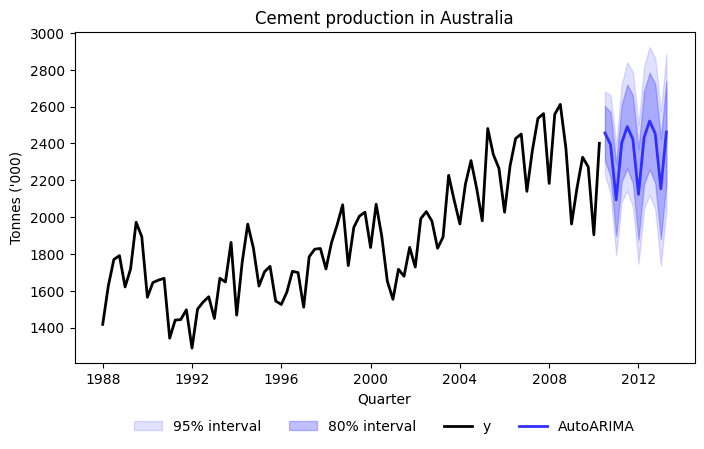

In [96]:
import matplotlib.pyplot as plt
from statsforecast.models import AutoARIMA
from statsforecast import StatsForecast

models = [AutoARIMA(season_length=4)]
sf = StatsForecast(models=models, freq="QS", n_jobs=-1)
fc = sf.forecast(h=12, df=cement, level=[80, 95])

fig, ax = plt.subplots(figsize=(8, 4.3))

ax.fill_between(
    fc["ds"], fc["AutoARIMA-lo-95"], fc["AutoARIMA-hi-95"],
    color="#2f2fff", alpha=0.15, label="95% interval",
)
ax.fill_between(
    fc["ds"], fc["AutoARIMA-lo-80"], fc["AutoARIMA-hi-80"],
    color="#2f2fff", alpha=0.30, label="80% interval",
)
ax.plot(cement["ds"], cement["y"], color="black", linewidth=2, label="y")
ax.plot(fc["ds"], fc["AutoARIMA"], color="#2f2fff", linewidth=2, label="AutoARIMA")

ax.set_title("Cement production in Australia")
ax.set_xlabel("Quarter")
ax.set_ylabel("Tonnes ('000)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)
plt.show()